<a href="https://colab.research.google.com/github/Derinhelm/treebank_statistics/blob/graph_statistics/treebank_graph_stat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка датасетов

In [ ]:
from IPython.display import clear_output

In [ ]:
!wget -m https://github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-train-a.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-train-b.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-train-c.conllu

!wget -m https://github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-dev.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-test.conllu

!mv /content/github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-train-a.conllu /content/ru_syntagrus-ud-train-a.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-train-b.conllu /content/ru_syntagrus-ud-train-b.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-train-c.conllu /content/ru_syntagrus-ud-train-c.conllu

!mv /content/github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-dev.conllu /content/ru_syntagrus-ud-dev.conllu

!mv /content/github.com/UniversalDependencies/UD_Russian-SynTagRus/raw/master/ru_syntagrus-ud-test.conllu /content/ru_syntagrus-ud-test.conllu

clear_output()

In [ ]:
!wget -m https://github.com/UniversalDependencies/UD_Russian-Taiga/raw/refs/heads/master/ru_taiga-ud-train.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-Taiga/raw/refs/heads/master/ru_taiga-ud-dev.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-Taiga/raw/refs/heads/master/ru_taiga-ud-test.conllu

!mv /content/github.com/UniversalDependencies/UD_Russian-Taiga/raw/refs/heads/master/ru_taiga-ud-train.conllu /content/ru_taiga-ud-train.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-Taiga/raw/refs/heads/master/ru_taiga-ud-dev.conllu /content/ru_taiga-ud-dev.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-Taiga/raw/refs/heads/master/ru_taiga-ud-test.conllu /content/ru_taiga-ud-test.conllu

clear_output()

In [ ]:
!wget -m https://github.com/UniversalDependencies/UD_Russian-Poetry/raw/refs/heads/master/ru_poetry-ud-train.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-Poetry/raw/refs/heads/master/ru_poetry-ud-dev.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-Poetry/raw/refs/heads/master/ru_poetry-ud-test.conllu

!mv /content/github.com/UniversalDependencies/UD_Russian-Poetry/raw/refs/heads/master/ru_poetry-ud-train.conllu /content/ru_poetry-ud-train.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-Poetry/raw/refs/heads/master/ru_poetry-ud-dev.conllu /content/ru_poetry-ud-dev.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-Poetry/raw/refs/heads/master/ru_poetry-ud-test.conllu /content/ru_poetry-ud-test.conllu

clear_output()

In [ ]:
!wget -m https://github.com/UniversalDependencies/UD_Russian-GSD/raw/refs/heads/master/ru_gsd-ud-train.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-GSD/raw/refs/heads/master/ru_gsd-ud-dev.conllu
!wget -m https://github.com/UniversalDependencies/UD_Russian-GSD/raw/refs/heads/master/ru_gsd-ud-test.conllu

!mv /content/github.com/UniversalDependencies/UD_Russian-GSD/raw/refs/heads/master/ru_gsd-ud-train.conllu /content/ru_gsd-ud-train.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-GSD/raw/refs/heads/master/ru_gsd-ud-dev.conllu /content/ru_gsd-ud-dev.conllu
!mv /content/github.com/UniversalDependencies/UD_Russian-GSD/raw/refs/heads/master/ru_gsd-ud-test.conllu /content/ru_gsd-ud-test.conllu

clear_output()

# Хранение токенов и предложения



In [ ]:
class ConllEntry:
    def __init__(self, id, form, lemma, pos, cpos, feats=None, \
                 parent_id=None, relation=None,deps=None, misc=None):
        self.id = id
        self.form = form
        self.lemma = lemma
        self.pos = pos
        self.cpos = cpos
        self.feats = feats
        self.parent_id = parent_id
        self.relation = relation
        self.deps = deps
        self.misc = misc
        self.root_depth = None

In [ ]:
import networkx as nx

class Sentence:
    def __init__(self):
        self.text = ""
        self.sent_id = ""
        self.tokens = []
        self.graph = None
        self.graph_depth = -1

    def add_token(self, token):
        self.tokens.append(token)

    def set_sent_id(self, sent_id):
        self.sent_id = sent_id

    def set_text(self, text):
        self.text = text

    def is_not_empty(self):
        return len(self.tokens) > 0

    def create_graph(self):
      self.graph = nx.DiGraph()
      self.graph.add_node('0', word='root')
      for w in self.tokens:
        self.graph.add_node(w.id, word=w.form)
      for w in self.tokens:
        self.graph.add_edge(w.parent_id, w.id, dep_rel=w.relation)

      for t in self.tokens:
          t.root_depth = nx.shortest_path_length(self.graph, '0', t.id) - 1
      self.graph_depth = max(t.root_depth for t in self.tokens)

# Чтение информации из файла

In [ ]:

def read_conll(filename):
    fh = open(filename,'r',encoding='utf-8')
    sents_read = 0
    sents = []
    comments = set()

    sent = Sentence()
    for line in fh:
        tok = line.strip().split('\t')
        if not tok or line.strip() == '': # empty line, add sentence to list
            if sent.is_not_empty:
                sents_read += 1
                sents.append(sent)
            sent = Sentence()
        else:
            if line[0] == '#' or '-' in tok[0]: # a comment line
                line = line.strip()
                if line[:12] == "# sent_id = ":
                    sent.set_sent_id(line[12:])
                elif line[:9] == "# text = ":
                    sent.set_text(line[9:])
                else:
                    comments.add(line)

            else: # an actual ConllEntry, add to tokens
                if tok[2] == "_":
                    tok[2] = tok[1].lower()

                token = ConllEntry(*tok)
                sent.add_token(token)
    fh.close()
    return sents

In [ ]:
treebank_names = [ "ru_taiga", "ru_poetry", "ru_syntagrus", "ru_gsd"]
sent_types = [ "train", "dev", "test" ]

In [ ]:
sents = { t: {} for t in treebank_names}
sents["ru_syntagrus"]["train"] = read_conll("/content/ru_syntagrus-ud-train-a.conllu") + \
                           read_conll("/content/ru_syntagrus-ud-train-b.conllu") + \
                           read_conll("/content/ru_syntagrus-ud-train-c.conllu")
sents["ru_syntagrus"]["dev"] = read_conll("/content/ru_syntagrus-ud-dev.conllu")
sents["ru_syntagrus"]["test"] = read_conll("/content/ru_syntagrus-ud-test.conllu")
for t in treebank_names:
  if t != "ru_syntagrus":
    sents[t]["train"] = read_conll(f"/content/{t}-ud-train.conllu")
    sents[t]["dev"] = read_conll(f"/content/{t}-ud-dev.conllu")
    sents[t]["test"] = read_conll(f"/content/{t}-ud-test.conllu")

In [ ]:
len(sents["ru_syntagrus"]['test'])

8800

In [ ]:
[(t.id, t.form) for t in sents["ru_syntagrus"]['test'][3946].tokens]

[('1', 'Почему'), ('1.1', '_'), ('2', 'к'), ('3', 'нему'), ('4', '?')]

In [ ]:
def delete_point_tokens(s):
  s.tokens = [t for t in s.tokens if "." not in t.id]
  return s

for t in treebank_names:
  for sent_type in sents[t]:
      sents[t][sent_type] = [delete_point_tokens(s) for s in sents[t][sent_type]]

In [ ]:
[(t.id, t.form) for t in sents["ru_syntagrus"]['test'][3946].tokens]

[('1', 'Почему'), ('2', 'к'), ('3', 'нему'), ('4', '?')]

In [ ]:
for t in treebank_names:
  for sent_type in sents[t]:
      for sent in sents[t][sent_type]:
          sent.create_graph()

In [ ]:
graph_depths = {}
for tr in treebank_names:
  graph_depths[tr] = {}
  for sent_type in sent_types:
    graph_depths[tr][sent_type] = [s. graph_depth for s in sents[tr][sent_type]]

In [ ]:
for tr in treebank_names:
  for sent_type in sent_types:
    print(tr, sent_type, sum(graph_depths[tr][sent_type]) / len(graph_depths[tr][sent_type]))

ru_taiga train 2.9105017139295732
ru_taiga dev 2.763213530655391
ru_taiga test 3.013620885357548
ru_poetry train 2.8680302605771923
ru_poetry dev 2.864385297845374
ru_poetry test 2.9766483516483517
ru_syntagrus train 4.0829958351285365
ru_syntagrus dev 4.037839658657085
ru_syntagrus test 4.105681818181818
ru_gsd train 4.3896103896103895
ru_gsd dev 4.419689119170984
ru_gsd test 4.1763727121464225


# Вычисление статистики по глубинам графов

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
def create_node_df(cur_sents):
    info = []
    for sent_i, sent in enumerate(cur_sents):
      for w_i, w in enumerate(sent.tokens):
        child_amount = len(sent.graph.succ[w.id])
        info.append((w.id, float(w.id) / len(sent.tokens), w.parent_id, float(w.parent_id) / len(sent.tokens),
                     w.relation, w.pos, w.form, w.lemma, int(w.id) - int(w.parent_id),
                     w.root_depth, (w.root_depth + 1) / (sent.graph_depth + 1), sent_i, child_amount))
    info_df = pd.DataFrame(info, columns=["id", "rate_id", "parent_id", "rate_parent_id", "relation", "pos",
                      "form", "lemma", "dep_length", "root_depth", "rate_root_depth", "sent_i", "child_amount"])
    return info_df

In [ ]:
node_df = {}
for tr in treebank_names:
    node_df[tr] = {}
    for sent_type in sent_types:
      node_df[tr][sent_type] = create_node_df(sents[tr][sent_type])

In [ ]:
node_df['ru_syntagrus']['train']['root_depth'].describe().round()

,root_depth
count,1204640.0
mean,3.0
std,2.0
min,0.0
25%,1.0
50%,2.0
75%,4.0
max,20.0


In [ ]:
for tr in treebank_names:
  print(tr, "\n", node_df[tr]['train']['root_depth'].describe().round(), "\n")

ru_taiga 
 count    176631.0
mean          2.0
std           2.0
min           0.0
25%           1.0
50%           2.0
75%           3.0
max          21.0
Name: root_depth, dtype: float64 

ru_poetry 
 count    43972.0
mean         2.0
std          1.0
min          0.0
25%          1.0
50%          2.0
75%          3.0
max          9.0
Name: root_depth, dtype: float64 

ru_syntagrus 
 count    1204640.0
mean           3.0
std            2.0
min            0.0
25%            1.0
50%            2.0
75%            4.0
max           20.0
Name: root_depth, dtype: float64 

ru_gsd 
 count    74900.0
mean         3.0
std          2.0
min          0.0
25%          1.0
50%          2.0
75%          4.0
max         14.0
Name: root_depth, dtype: float64 



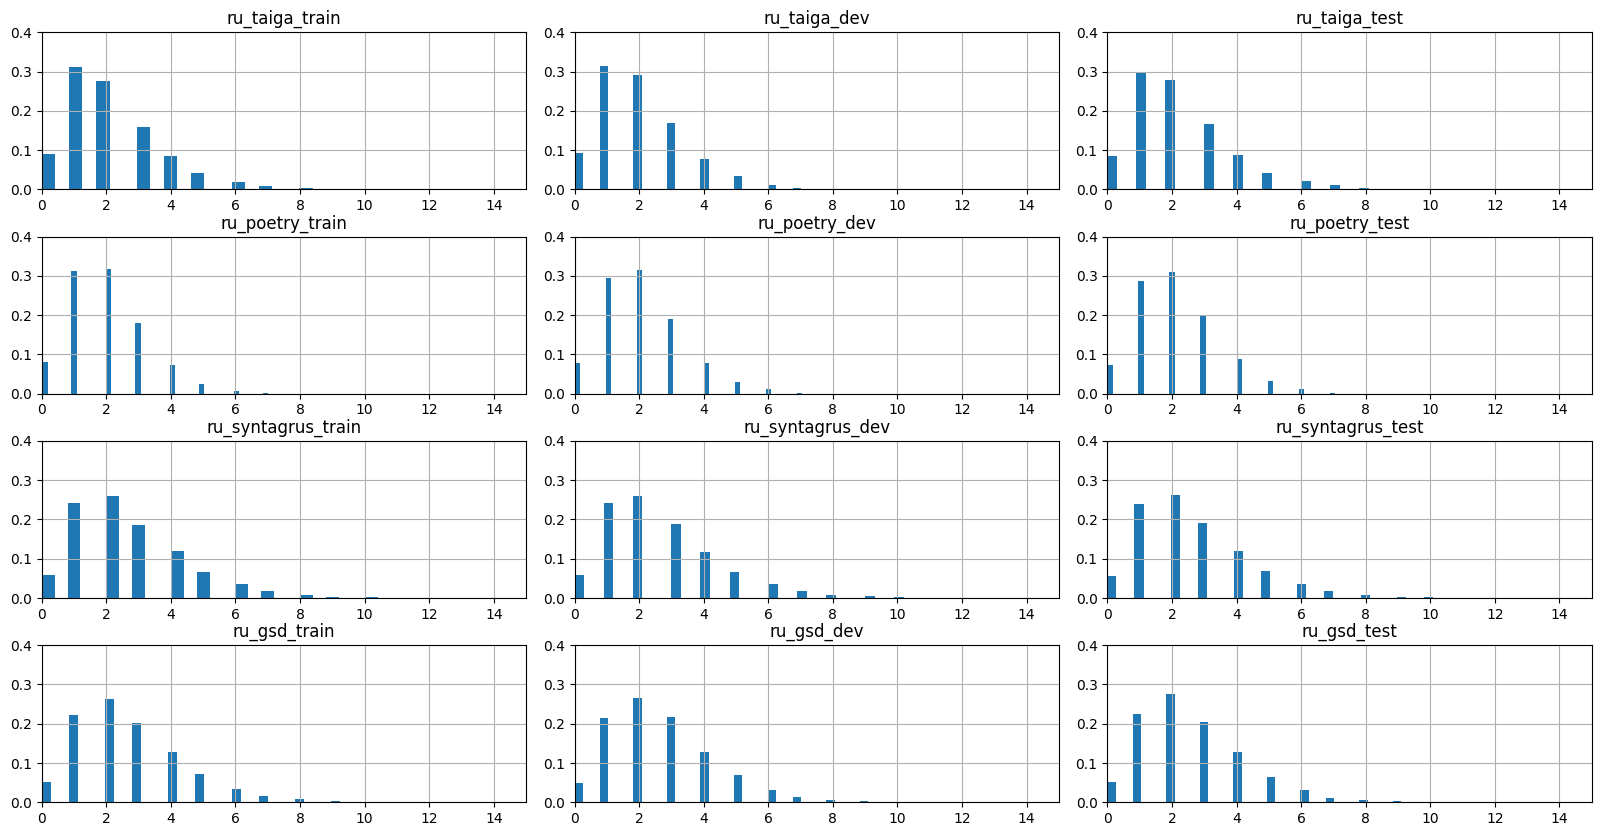

In [ ]:
fig, axs = plt.subplots(len(treebank_names), len(sent_types), figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
for tr_i, tr in enumerate(treebank_names):
    for sent_type_i, sent_type in enumerate(sent_types):
      data_len = len(node_df[tr][sent_type]['root_depth'])
      node_df[tr][sent_type]['root_depth'].hist(bins=50,
                                                ax=axs[tr_i][sent_type_i],
                                                weights=np.ones(data_len)/data_len)
      axs[tr_i][sent_type_i].set_title(f"{tr}_{sent_type}")
      axs[tr_i][sent_type_i].set_xlim(0, 15)
      axs[tr_i][sent_type_i].set_ylim(0, 0.4)

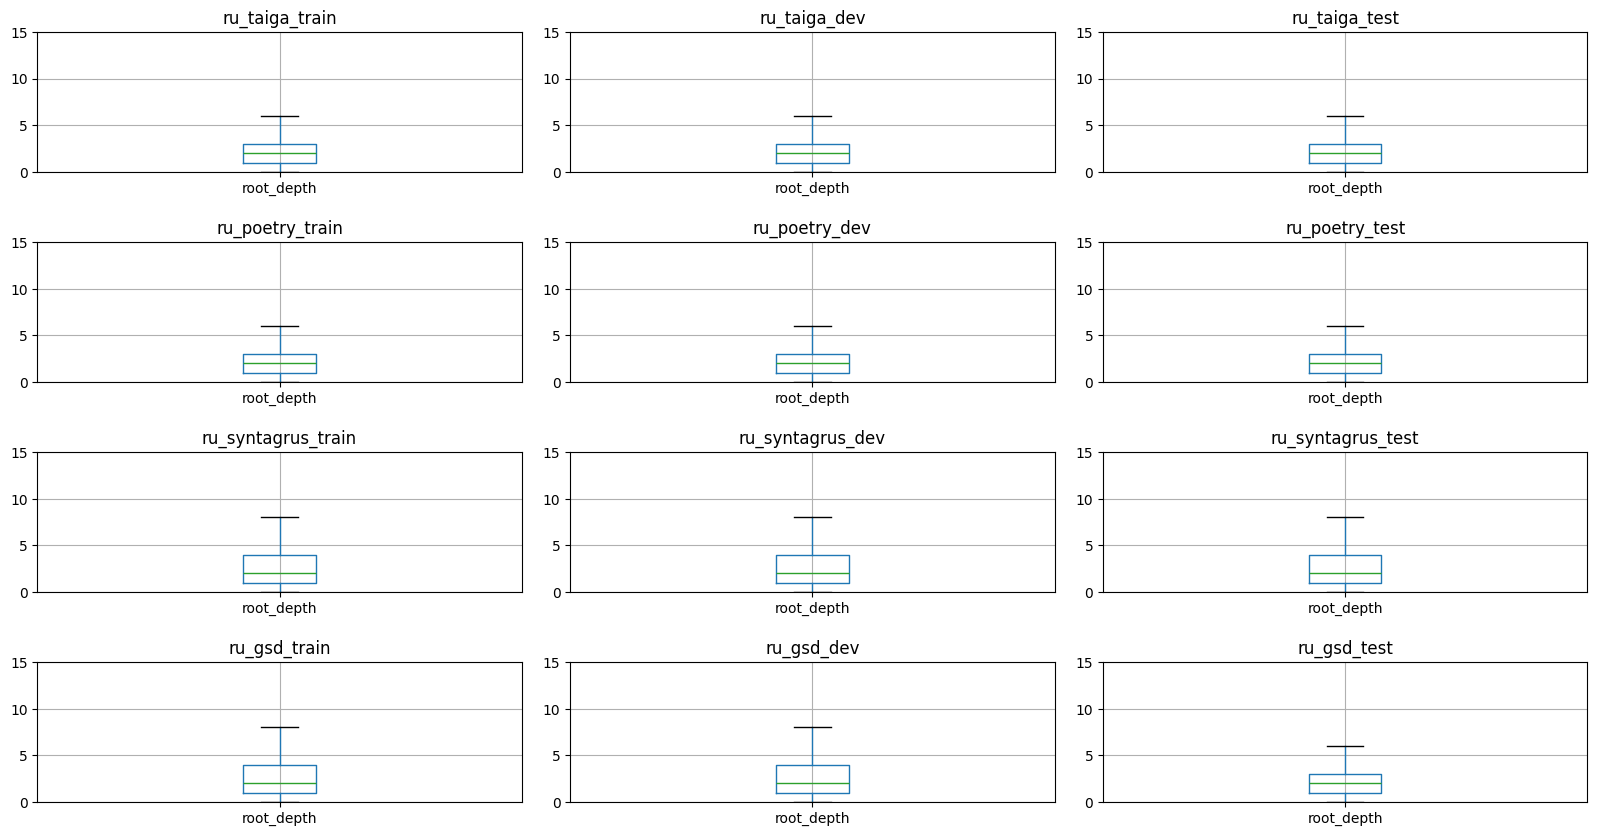

In [ ]:
fig, axs = plt.subplots(len(treebank_names), len(sent_types), figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.5)
for tr_i, tr in enumerate(treebank_names):
    for sent_type_i, sent_type in enumerate(sent_types):
      data_len = len(node_df[tr][sent_type]['root_depth'])
      node_df[tr][sent_type].boxplot(showfliers=False,
          column='root_depth', ax=axs[tr_i][sent_type_i])
      axs[tr_i][sent_type_i].set_title(f"{tr}_{sent_type}")
#      axs[tr_i][sent_type_i].set_xlim(0, 15)
      axs[tr_i][sent_type_i].set_ylim(0, 15)

## С группировкой по предложениям

In [ ]:
for tr in treebank_names:
  print(tr, "\n", (node_df[tr]['train'].groupby('sent_i')['root_depth'].mean()).describe().round(2), "\n")

ru_taiga 
 count    16045.00
mean         1.58
std          0.80
min          0.00
25%          1.00
50%          1.43
75%          2.00
max          9.64
Name: root_depth, dtype: float64 

ru_poetry 
 count    3569.00
mean        1.54
std         0.71
min         0.00
25%         1.00
50%         1.55
75%         2.00
max         4.67
Name: root_depth, dtype: float64 

ru_syntagrus 
 count    69630.00
mean         2.13
std          0.94
min          0.50
25%          1.44
50%          2.00
75%          2.65
max          9.59
Name: root_depth, dtype: float64 

ru_gsd 
 count    3850.00
mean        2.26
std         0.84
min         0.50
25%         1.67
50%         2.14
75%         2.70
max         7.24
Name: root_depth, dtype: float64 



In [ ]:
for tr in treebank_names:
  print(tr, "\n", (node_df[tr]['train'].groupby('sent_i')['rate_root_depth'].mean()).describe().round(2), "\n")

ru_taiga 
 count    16045.00
mean         0.69
std          0.10
min          0.40
25%          0.62
50%          0.67
75%          0.75
max          1.00
Name: rate_root_depth, dtype: float64 

ru_poetry 
 count    3569.00
mean        0.69
std         0.11
min         0.44
25%         0.61
50%         0.67
75%         0.75
max         1.00
Name: rate_root_depth, dtype: float64 

ru_syntagrus 
 count    69630.00
mean         0.64
std          0.09
min          0.38
25%          0.58
50%          0.63
75%          0.69
max          0.94
Name: rate_root_depth, dtype: float64 

ru_gsd 
 count    3850.00
mean        0.62
std         0.08
min         0.43
25%         0.57
50%         0.62
75%         0.67
max         0.92
Name: rate_root_depth, dtype: float64 



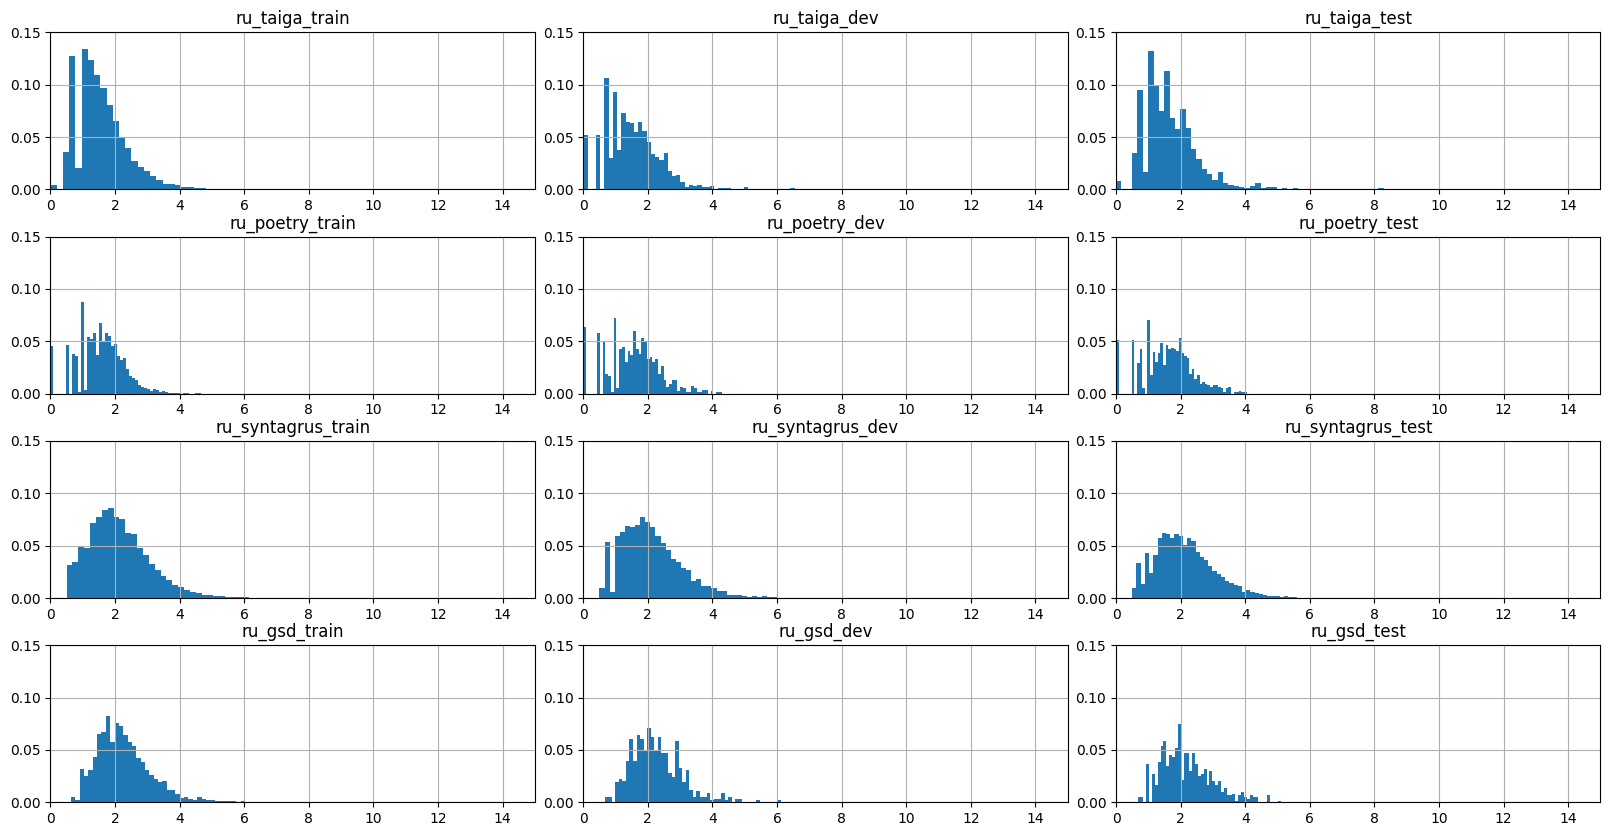

In [ ]:
fig, axs = plt.subplots(len(treebank_names), len(sent_types), figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
for tr_i, tr in enumerate(treebank_names):
    for sent_type_i, sent_type in enumerate(sent_types):
      data = node_df[tr][sent_type].groupby('sent_i')['root_depth'].mean()
      data_len = len(node_df[tr][sent_type]['root_depth'])
      data.hist(bins=50,
                                        ax=axs[tr_i][sent_type_i],
                                        weights=np.ones(len(data))/len(data))
      axs[tr_i][sent_type_i].set_title(f"{tr}_{sent_type}")
      axs[tr_i][sent_type_i].set_xlim(0, 15)
      axs[tr_i][sent_type_i].set_ylim(0, 0.15)

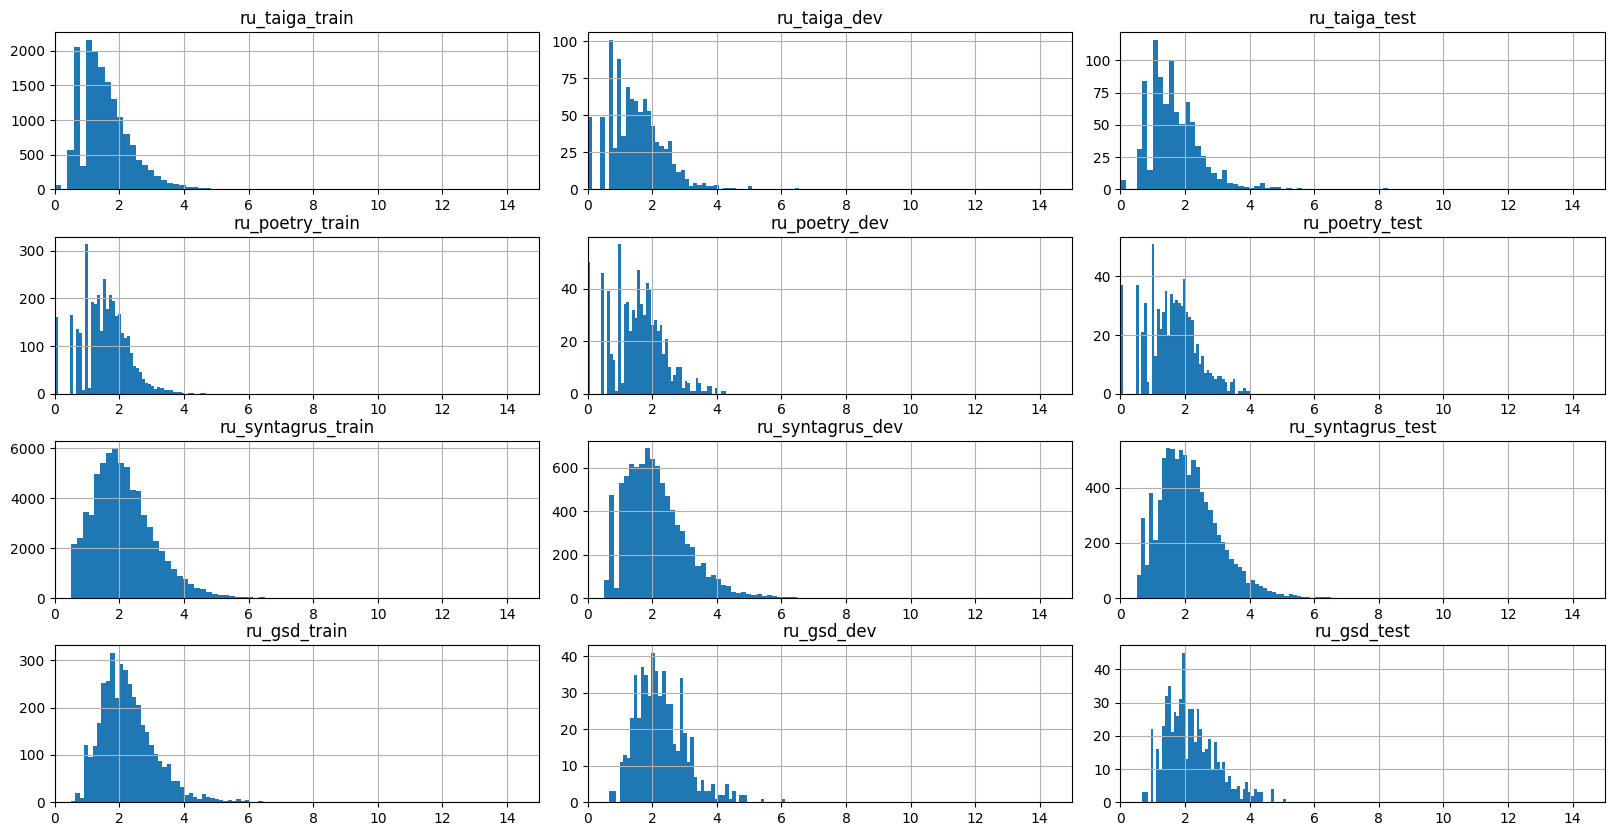

In [ ]:
fig, axs = plt.subplots(len(treebank_names), len(sent_types), figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
for tr_i, tr in enumerate(treebank_names):
    for sent_type_i, sent_type in enumerate(sent_types):
      data = node_df[tr][sent_type].groupby('sent_i')['root_depth'].mean()
      data_len = len(node_df[tr][sent_type]['root_depth'])
      data.hist(bins=50,
                                        ax=axs[tr_i][sent_type_i])
      axs[tr_i][sent_type_i].set_title(f"{tr}_{sent_type}")
      axs[tr_i][sent_type_i].set_xlim(0, 15)
#      axs[tr_i][sent_type_i].set_ylim(0, 0.15)

In [ ]:
counter_root_depth = node_df[tr][sent_type].groupby('sent_i')['root_depth'].apply(Counter)

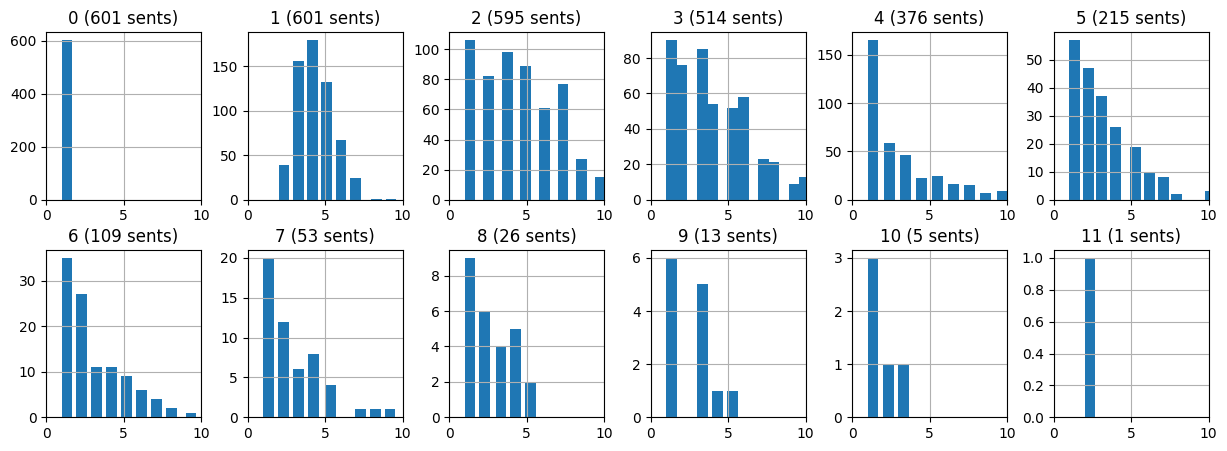

In [ ]:
# Распределение по предложениям количества токенов глубины i
fig, axs = plt.subplots(2, 6, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for i in range(12):
  counter_root_depth.loc[:, i].dropna().hist(bins=50, ax=axs[i // 6][i % 6], width=0.7)
  axs[i // 6][i % 6].set_title(f"{i} ({len(counter_root_depth.loc[:, i].dropna())} sents)")
  axs[i // 6][i % 6].set_xlim(0, 10)

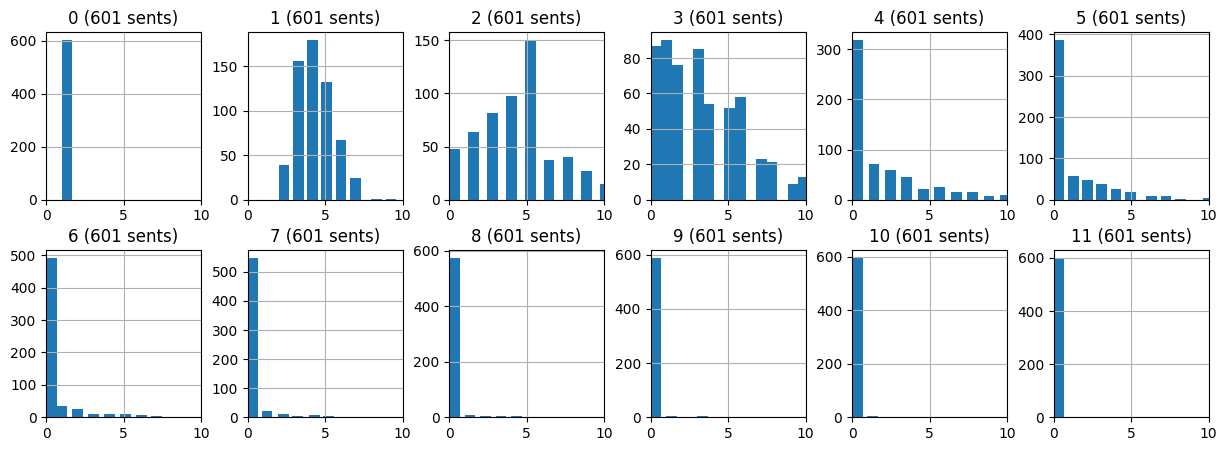

In [ ]:
# Распределение по предложениям количества токенов глубины i
fig, axs = plt.subplots(2, 6, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for i in range(12):
  counter_root_depth.loc[:, i].fillna(0).hist(bins=50, ax=axs[i // 6][i % 6], width=0.7)
  axs[i // 6][i % 6].set_title(f"{i} ({len(counter_root_depth.loc[:, i].fillna(0))} sents)")
  axs[i // 6][i % 6].set_xlim(0, 10)


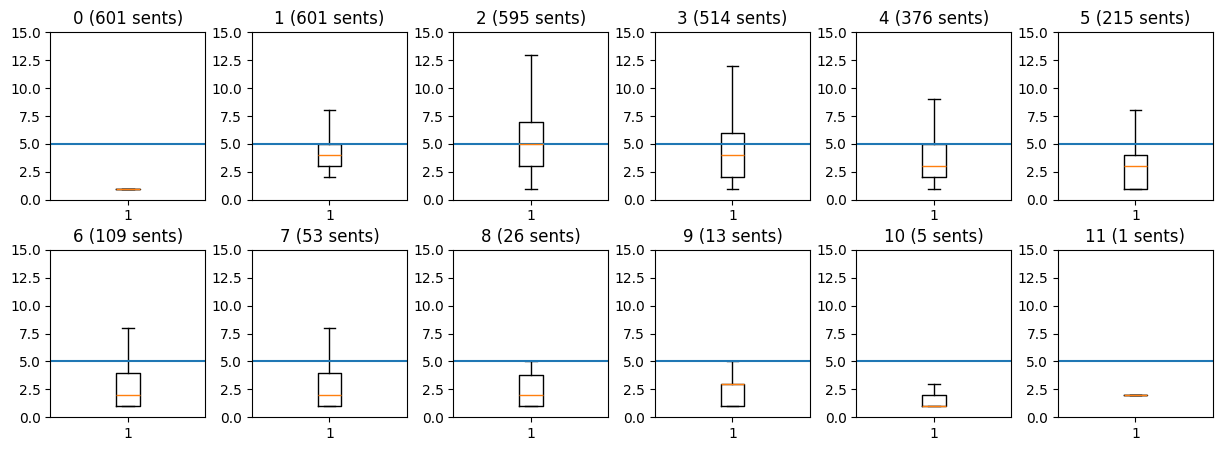

In [ ]:
# Распределение по предложениям количества токенов глубины i
fig, axs = plt.subplots(2, 6, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for i in range(12):
  axs[i // 6][i % 6].boxplot(counter_root_depth.loc[:, i].dropna(), showfliers=False)
  axs[i // 6][i % 6].set_title(f"{i} ({len(counter_root_depth.loc[:, i].dropna())} sents)")
  axs[i // 6][i % 6].set_ylim(0, 15)
  axs[i // 6][i % 6].axhline(5)

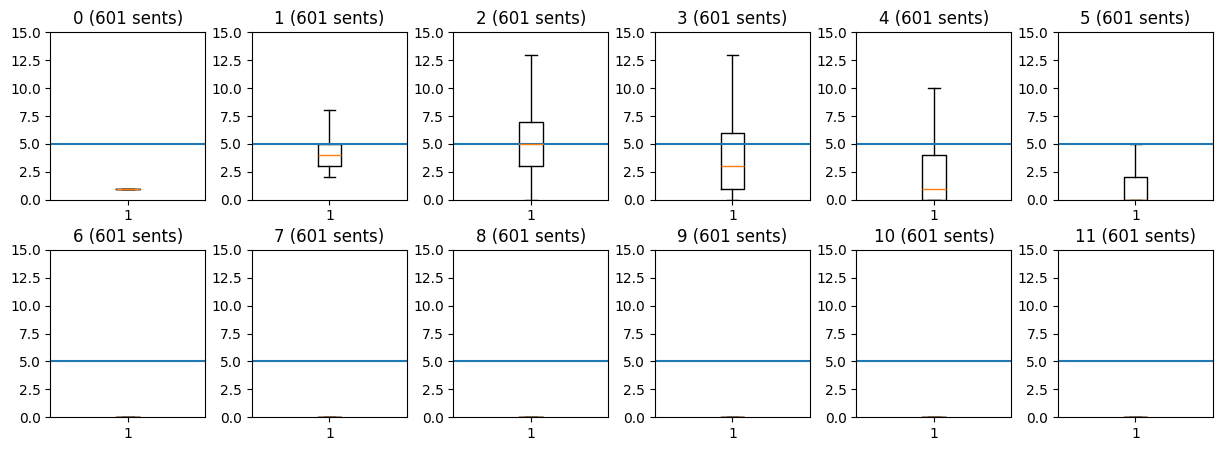

In [ ]:
# Распределение по предложениям количества токенов глубины i
fig, axs = plt.subplots(2, 6, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for i in range(12):
  axs[i // 6][i % 6].boxplot(counter_root_depth.loc[:, i].fillna(0), showfliers=False)
  axs[i // 6][i % 6].set_title(f"{i} ({len(counter_root_depth.loc[:, i].fillna(0))} sents)")
  axs[i // 6][i % 6].set_ylim(0, 15)
  axs[i // 6][i % 6].axhline(5)

## Среднее количество токенов определенной глубины по предложениям

In [ ]:
len(counter_root_depth[0])

14

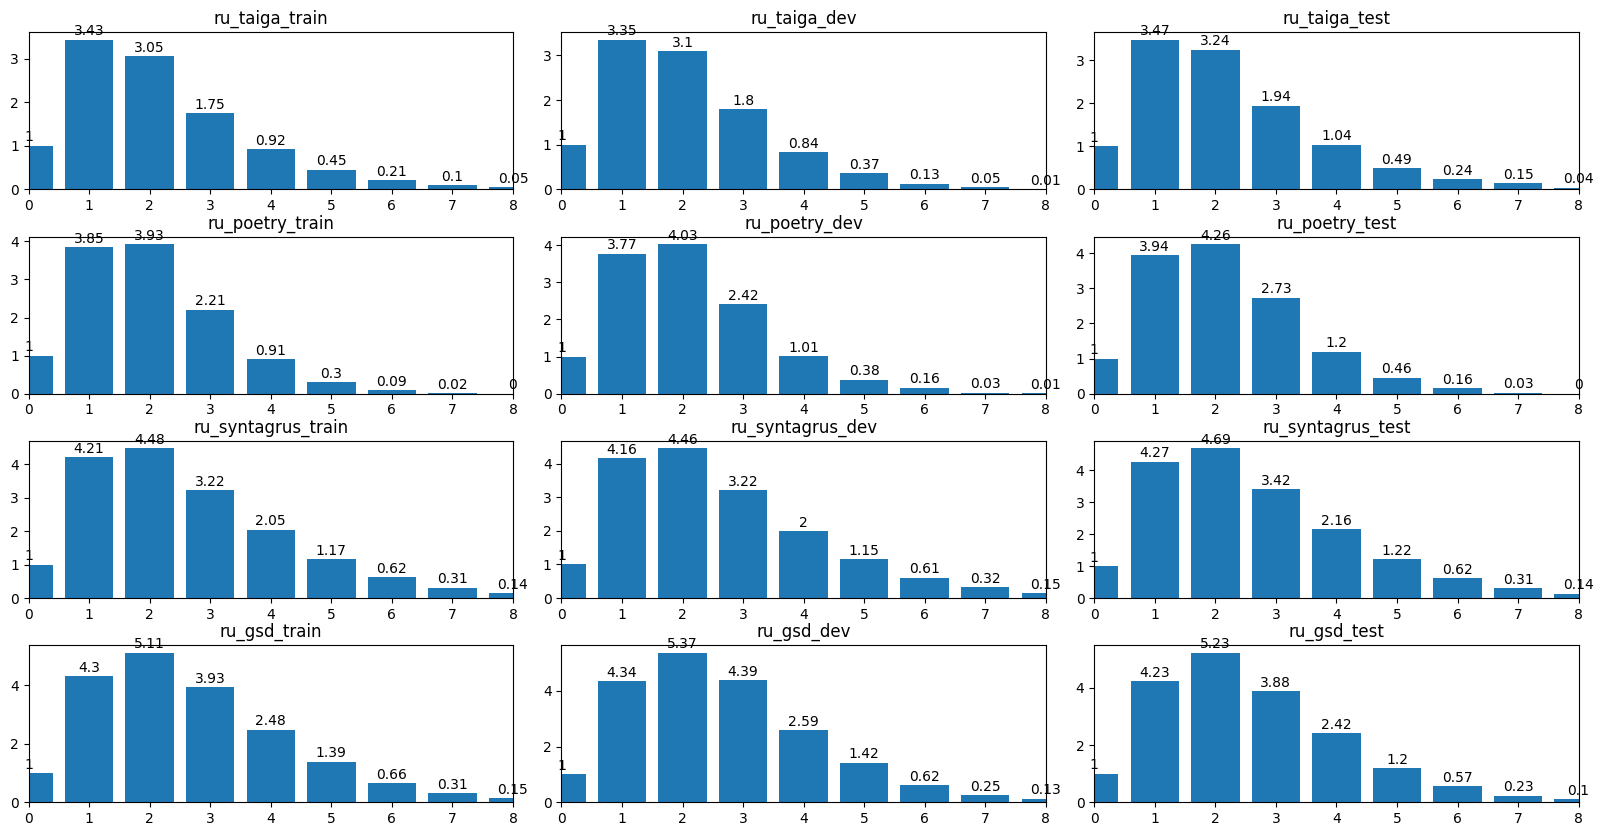

In [ ]:
# Среднее количество токенов определенной глубины по предложениям
fig, axs = plt.subplots(len(treebank_names), len(sent_types), figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
for tr_i, tr in enumerate(treebank_names):
    for sent_type_i, sent_type in enumerate(sent_types):
      counter_root_depth = node_df[tr][sent_type].groupby('sent_i')['root_depth'].apply(Counter)
      d = []
      dep_len = len(counter_root_depth[0])
      for i in range(dep_len):
          d.append(counter_root_depth[:,i].fillna(0).mean().round(2))
      rects =  axs[tr_i][sent_type_i].bar(range(dep_len), d)
      axs[tr_i][sent_type_i].bar_label(rects, padding=1)
      axs[tr_i][sent_type_i].set_title(f"{tr}_{sent_type}")
      axs[tr_i][sent_type_i].set_xlim(0, 8)
plt.show()

# Количество дочерних токенов

## Среднее количество токенов с определенным количеством потомков в предложении

In [ ]:
node_df[tr][sent_type][node_df[tr][sent_type]['sent_i']==448]

,id,rate_id,parent_id,rate_parent_id,relation,pos,form,lemma,dep_length,root_depth,rate_root_depth,sent_i,child_amount
7936,1,0.004975,3,0.014925,nsubj,NOUN,Англичане,англичанин,-2,1,0.285714,448,0
7937,2,0.009950,3,0.014925,advmod,ADV,традиционно,традиционно,-1,1,0.285714,448,0
7938,3,0.014925,0,0.000000,root,VERB,называли,называть,3,0,0.142857,448,25
7939,4,0.019900,3,0.014925,obj,PRON,их,они,1,1,0.285714,448,0
7940,5,0.024876,3,0.014925,xcomp,X,Gypsies,gypsies,2,1,0.285714,448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8132,197,0.980100,196,0.975124,punct,PUNCT,&#39;&#39;,&#39;&#39;,1,4,0.714286,448,0
8133,198,0.985075,196,0.975124,punct,PUNCT,--,--,2,4,0.714286,448,0
8134,199,0.990050,196,0.975124,appos,ADJ,чёрный,черный,3,4,0.714286,448,0
8135,200,0.995025,196,0.975124,punct,PUNCT,),),4,4,0.714286,448,0


In [ ]:
[(i1, i2) for (i1, i2) in counter_root_depth.index if i2 > 10]

[(431, 11), (448, 25), (530, 11)]

In [ ]:
max(list(map(lambda x: x[1], counter_root_depth.dropna().index)))

25

In [ ]:
counter_root_depth

sent_i  child_amount
0       0               15.0
        5                2.0
        1                2.0
        3                1.0
        2                4.0
                        ... 
599     4                1.0
600     0               12.0
        1                2.0
        3                4.0
        2                3.0
Name: child_amount, Length: 2768, dtype: float64

ru_taiga train [(55, 13), (710, 11), (2775, 23), (2960, 11), (3012, 14), (3743, 12), (4185, 12), (7862, 11), (12442, 12), (12532, 19), (13088, 11), (13583, 19), (14101, 36), (14344, 12), (14529, 11), (14632, 11), (14685, 13), (14963, 39), (15439, 18), (15590, 11), (15653, 15), (15821, 11), (15942, 11), (15973, 11)]
ru_taiga dev [(44, 30), (48, 25), (69, 28), (150, 16), (242, 29), (275, 24), (496, 18), (538, 27)]
ru_taiga test [(383, 13)]
ru_poetry train []
ru_poetry dev [(200, 11)]
ru_poetry test []
ru_syntagrus train [(1232, 11), (1326, 11), (1857, 14), (2123, 13), (3234, 13), (3382, 12), (3863, 12), (3878, 16), (4186, 12), (4199, 12), (4232, 16), (4238, 12), (4241, 13), (4271, 15), (4275, 13), (4285, 11), (4341, 11), (4349, 11), (4378, 11), (4383, 13), (4427, 12), (4431, 11), (4457, 18), (4527, 17), (7275, 12), (8953, 11), (9002, 11), (10045, 11), (11686, 12), (12411, 13), (12463, 11), (12512, 13), (12601, 11), (13529, 12), (13918, 11), (15008, 12), (16294, 16), (16813, 20), (17686, 

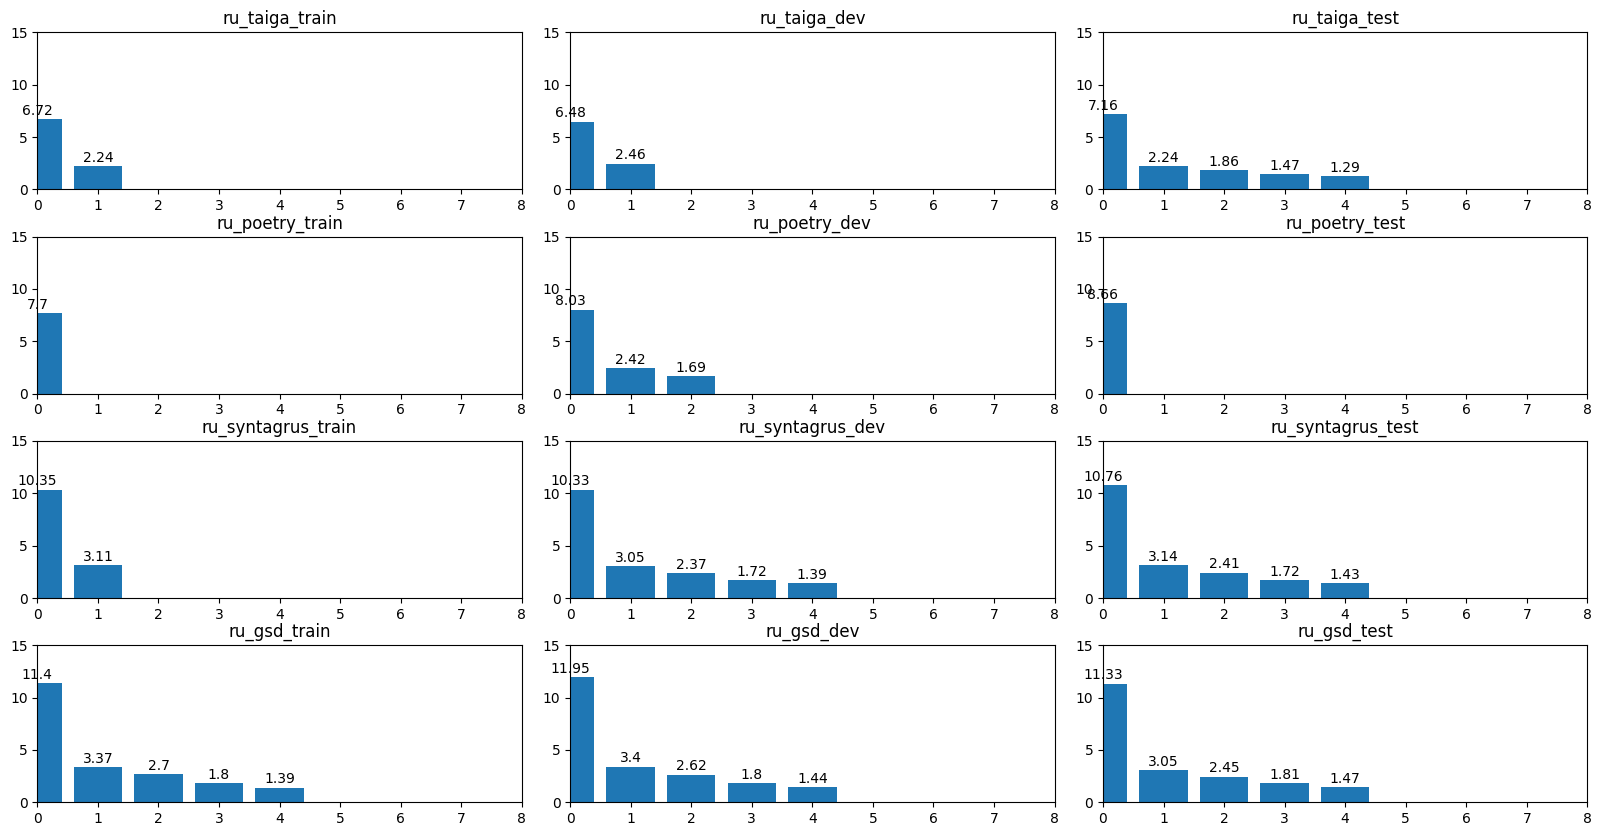

In [ ]:
# Среднее количество токенов определенной глубины по предложениям
fig, axs = plt.subplots(len(treebank_names), len(sent_types), figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
for tr_i, tr in enumerate(treebank_names):
    for sent_type_i, sent_type in enumerate(sent_types):
      counter_root_depth = node_df[tr][sent_type].groupby('sent_i')['child_amount'].apply(Counter)
      counter_root_depth.dropna(inplace=True)
      counter_root_depth.index.set_names(['sent_i', 'child_amount'], inplace=True)
      d = []
      dep_len = len(counter_root_depth[0])
      print(tr, sent_type, [(i1, i2) for (i1, i2) in counter_root_depth.index if i2 > 10])
      for i in range(dep_len):
          d.append(counter_root_depth[:,i].fillna(0).mean().round(2))
      rects =  axs[tr_i][sent_type_i].bar(range(dep_len), d)
      axs[tr_i][sent_type_i].bar_label(rects, padding=1)
      axs[tr_i][sent_type_i].set_title(f"{tr}_{sent_type}")
      axs[tr_i][sent_type_i].set_xlim(0, 8)
      axs[tr_i][sent_type_i].set_ylim(0, 15)

plt.show()

## Глубина и количество дочерних токенов (без аггрегации по предложениям)

In [ ]:
node_df[tr][sent_type].groupby(['child_amount', 'root_depth'])['sent_i'].apply(list).dropna()

child_amount  root_depth
0             1             [0, 0, 1, 1, 1, 2, 3, 4, 4, 5, 6, 7, 7, 7, 8, ...
              2             [0, 0, 0, 0, 1, 1, 1, 1, 3, 3, 4, 5, 5, 5, 5, ...
              3             [0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 4, 5, 5, 5, ...
              4             [0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 6, 6, 7, 8, 9, ...
              5             [2, 2, 2, 9, 11, 11, 11, 11, 11, 11, 11, 14, 1...
                                                  ...                        
8             3                                                         [394]
9             0                                                         [154]
11            0                                                         [431]
              2                                                         [530]
25            0                                                         [448]
Name: sent_i, Length: 78, dtype: object

In [ ]:
node_df[tr][sent_type].groupby(['child_amount', 'root_depth'])['sent_i'].count().rename('sent_count')

child_amount  root_depth
0             1             1126
              2             2037
              3             1597
              4             1055
              5              541
                            ... 
8             3                1
9             0                1
11            0                1
              2                1
25            0                1
Name: sent_count, Length: 78, dtype: int64

In [ ]:
data[6].sum()

133

In [ ]:
node_df[tr][sent_type]

,id,rate_id,parent_id,rate_parent_id,relation,pos,form,lemma,dep_length,root_depth,rate_root_depth,sent_i,child_amount
0,1,0.041667,2,0.083333,nsubj,PROPN,Билли,Билли,-1,1,0.400,0,0
1,2,0.083333,0,0.000000,root,VERB,начал,начать,2,0,0.200,0,5
2,3,0.125000,2,0.083333,xcomp,VERB,играть,играть,1,1,0.400,0,1
3,4,0.166667,6,0.250000,case,ADP,за,за,-2,3,0.800,0,0
4,5,0.208333,6,0.250000,amod,ADJ,резервный,резервный,-1,3,0.800,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11380,17,0.809524,16,0.761905,obj,NOUN,Землю,земля,1,6,0.875,600,0
11381,18,0.857143,19,0.904762,case,ADP,ради,ради,-1,7,1.000,600,0
11382,19,0.904762,16,0.761905,obl,NOUN,получения,получение,3,6,0.875,600,2
11383,20,0.952381,19,0.904762,nmod,NOUN,энергии,энергия,1,7,1.000,600,0


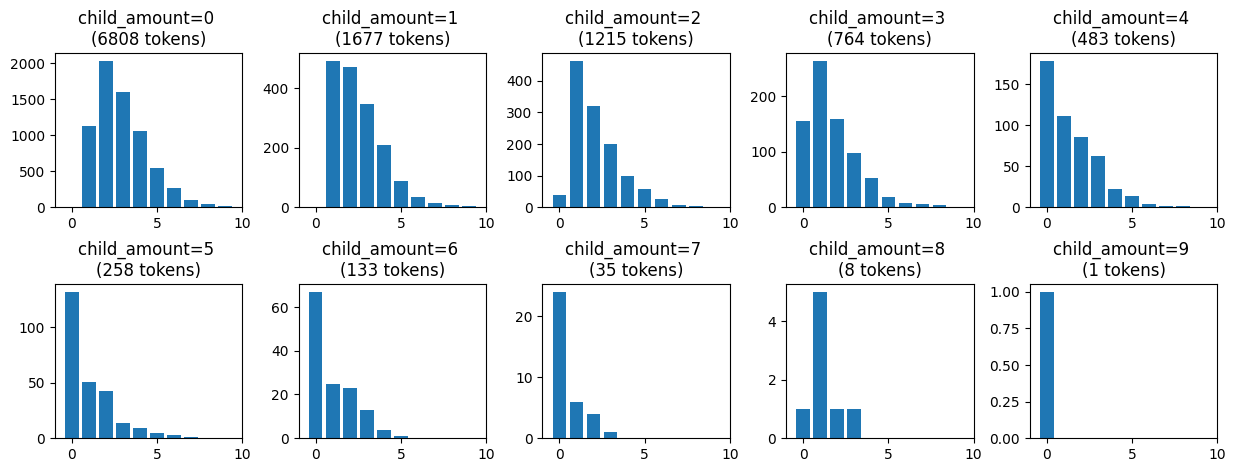

In [ ]:
# Количество токенов с определенным количество дочерних и определенной глубиной
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.5)

data = node_df[tr][sent_type].groupby(['child_amount', 'root_depth'])['sent_i'].count().rename('sent_count').dropna()
for i in range(10):
  axs[i // 5][i % 5].bar(data[i].index, data[i].values)
  axs[i // 5][i % 5].set_title(f"child_amount={i} \n({data[i].sum()} tokens)")
  #axs[i // 5][i % 5].set_ylim(0, 15)
  axs[i // 5][i % 5].set_xlim(-1, 10)
#plt.title('Глубина в зависимости от количества дочерних')

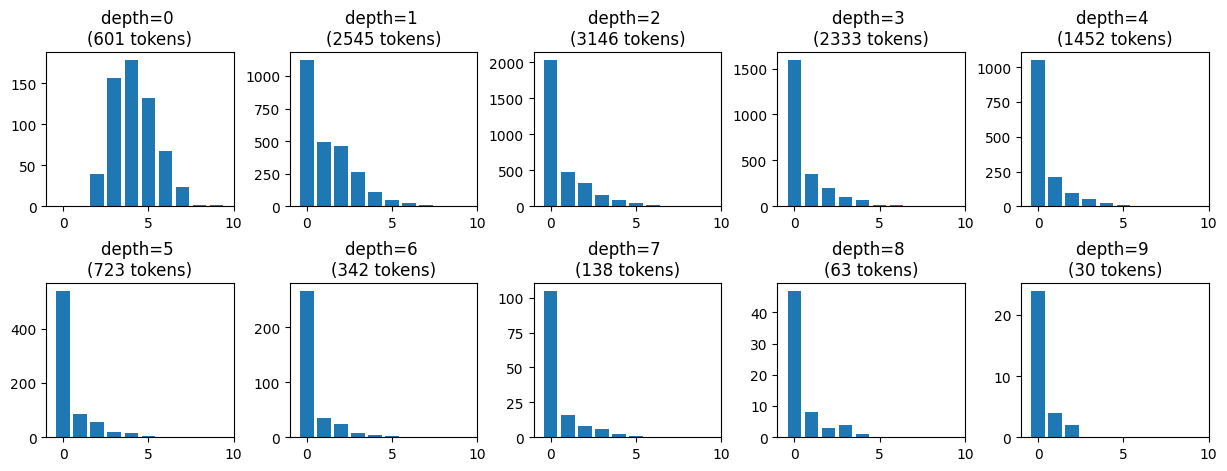

In [ ]:
# Количество токенов с определенным количество дочерних и определенной глубиной
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.5)

data = node_df[tr][sent_type].groupby(['child_amount', 'root_depth'])['sent_i'].count().rename('sent_count').dropna()
for i in range(10):
  axs[i // 5][i % 5].bar(data[:, i].index, data[:, i].values)
  axs[i // 5][i % 5].set_title(f"depth={i} \n({data[:, i].sum()} tokens)")
  #axs[i // 5][i % 5].set_ylim(0, 15)
  axs[i // 5][i % 5].set_xlim(-1, 10)


In [ ]:
data[:,4].index

Index([0, 1, 2, 3, 4, 5, 6], dtype='int64', name='child_amount')

# Визуализация

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


def draw_dependency_tree(g, title):
    plt.figure(figsize=(18, 6))
    levels = defaultdict(list)
    for node, level in nx.shortest_path_length(g, source="0").items():
        levels[-level].append(node)
    for level in levels:
        levels[level] = sorted(levels[level], key=lambda n: int(n))
    add_level = min(levels) - 1
    real_nodes = list(g.nodes())
    pos = nx.multipartite_layout(g, subset_key=levels, align='horizontal')
    for node in pos:
      pos[node][0] = int(node)
    node_labels = {node: f"[{node}]\n{g.nodes[node]['word']}" for node in g.nodes()}
    edge_colors = [ 'black' for u, v in g.edges() ]
    nx.draw(g, pos, with_labels=True, edge_color=edge_colors, labels=node_labels,
            node_size=300, node_color='white', font_size=8, font_weight='bold', arrows=False)
    labels = nx.get_edge_attributes(g, 'dep_rel')
    nx.draw_networkx_edge_labels(g, pos, edge_labels=labels)
    plt.title(title)
    plt.show()

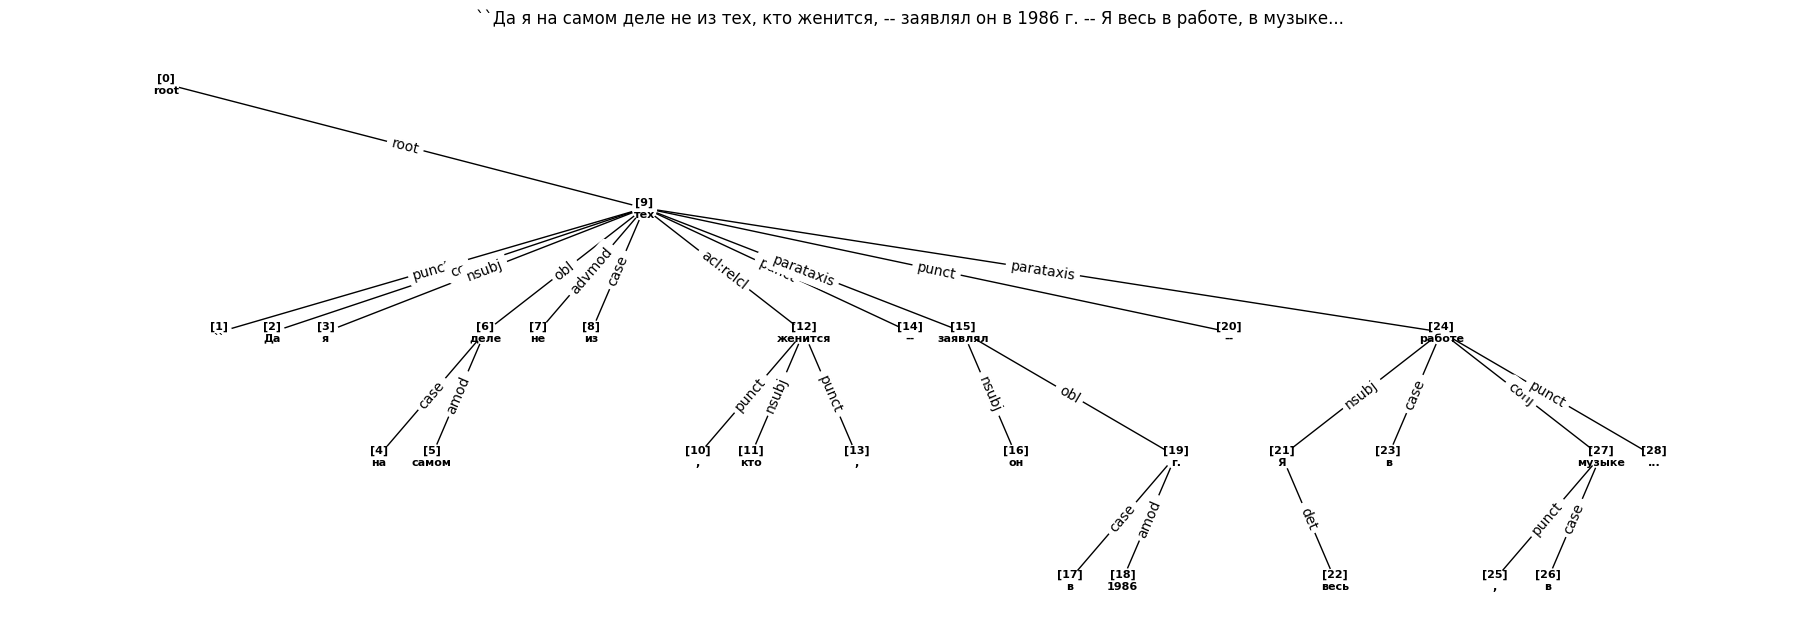

In [ ]:
draw_dependency_tree(sents['ru_gsd']['test'][431].graph, sents['ru_gsd']['test'][431].text)

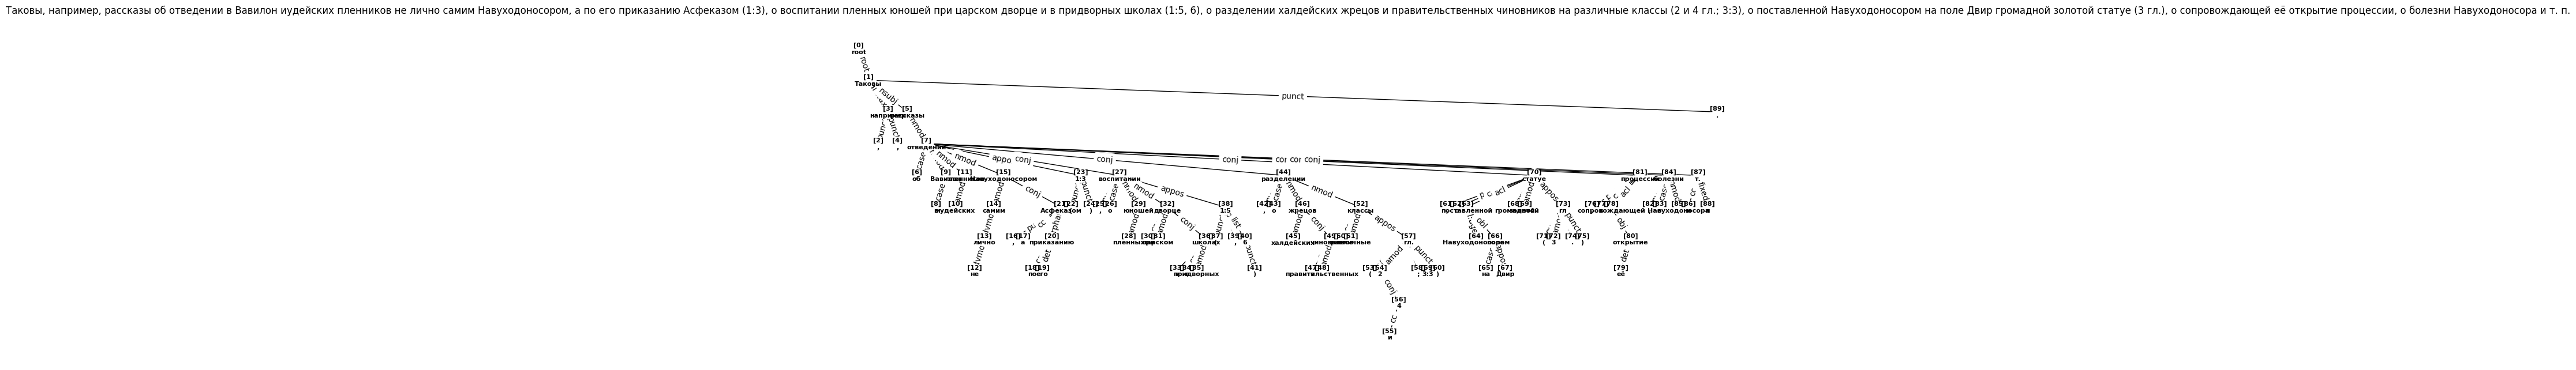

In [ ]:
draw_dependency_tree(sents['ru_gsd']['test'][530].graph, sents['ru_gsd']['test'][530].text)

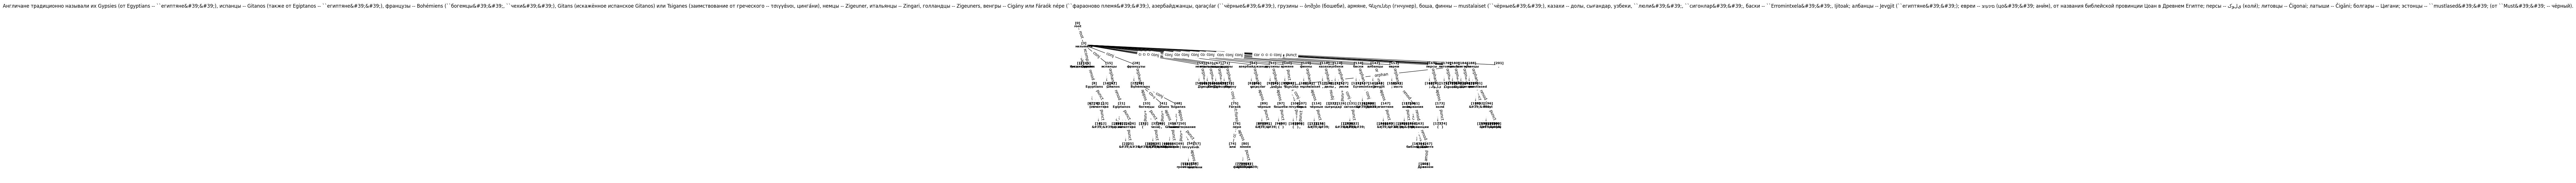

In [ ]:
draw_dependency_tree(sents['ru_gsd']['test'][448].graph, sents['ru_gsd']['test'][448].text)

# Старое

In [ ]:
abs_len_df = pd.DataFrame({ (tr, sent_type): [0]*50 for tr in treebank_names for sent_type in sent_types}, index=list(range(1, 51)))
abs_len_df.columns.names = ['treebank', 'sent_type']
rel_len_df = pd.DataFrame({ (tr, sent_type): [0]*50 for tr in treebank_names for sent_type in sent_types}, index=list(range(1, 51)))
rel_len_df.columns.names = ['treebank', 'sent_type']

for t in treebank_names:
  for sent_type in sents[t]:
      cur_len = Counter(len(s.tokens) for s in sents[t][sent_type])
      abs_len_df[t, sent_type] = [(cur_len[i] if i in cur_len else 0)
                                      for i in abs_len_df.index]
      rel_len_df[t, sent_type] = [(cur_len[i] / cur_len.total() if i in cur_len else 0)
                                      for i in rel_len_df.index]

In [ ]:
abs_len_df.head(10)

In [ ]:
rel_len_df.head(10).round(4)

In [ ]:
for tr in treebank_names:
  print(tr,
        max((rel_len_df[tr]['train'] - rel_len_df[tr]['dev']).round(5).abs()),
        max((rel_len_df[tr]['train'] - rel_len_df[tr]['test']).round(5).abs()),
        max((rel_len_df[tr]['dev'] - rel_len_df[tr]['test']).round(5).abs()))


# Старое


## Диаграмма Boxplot

In [ ]:
len_dict = { t : {} for t in treebank_names }
for t in treebank_names:

  for sent_type in sents[t]:
      len_dict[t][sent_type] = pd.DataFrame([len(s.tokens) for s in sents[t][sent_type]], columns=['sent_len'])


In [ ]:
for tr in treebank_names:
    print(tr, sent_type, [len_dict[tr][sent_type].mean().round(1).values[0] for sent_type in sent_types])

In [ ]:
f, axs = plt.subplots(1, 1, figsize=(8, 4))
for tr_i, tr in enumerate(treebank_names):
  box = axs.boxplot(len_dict[tr]['train'].values, positions=[tr_i], showfliers=False,
                    tick_labels=[""], showmeans=False, medianprops={'linewidth':0},
                    patch_artist=True, notch=True, label='train' if tr_i == 0 else "")
  box['boxes'][0].set(hatch = '//')
  box['boxes'][0].set(facecolor = 'white')
  box = axs.boxplot(len_dict[tr]['dev'].values, positions=[tr_i + 0.2], showfliers=False,
              tick_labels=[tr], showmeans=False, medianprops={'linewidth':0},
              patch_artist=True, notch=True, label='dev' if tr_i == 0 else "")
  box['boxes'][0].set(hatch = '\\\\')
  box['boxes'][0].set(facecolor = 'white')
  box = axs.boxplot(len_dict[tr]['test'].values, positions=[tr_i + 0.4], showfliers=False,
              tick_labels=[""], showmeans=False, medianprops={'linewidth':0},
              patch_artist=True, notch=True, label='test' if tr_i == 0 else "")
  box['boxes'][0].set(hatch = '--')
  box['boxes'][0].set(facecolor = 'white')
axs.axhline(10, color='black', alpha=0.5, linewidth=0.5)
axs.axhline(20, color='black', alpha=0.5, linewidth=0.5)
axs.set_ylabel('Длина предложения')
axs.set_xlabel('Датасеты')
axs.legend()

plt.savefig('sentence_length_boxplot.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## Распределение длин предложений

In [ ]:
f, axs = plt.subplots(3, 4, figsize=(12, 8))

ax_dict = { 0: axs[0][0], 1: axs[0][1],
            2: axs[1][0], 3: axs[1][1] }
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for tr_i, tr in enumerate(treebank_names):
  for sent_type_i, sent_type in enumerate(sent_types):
    cur_ax = axs[sent_type_i][tr_i]
    cur_ax.bar(rel_len_df.index[:30], rel_len_df[tr][sent_type][:30], label=sent_type,
               facecolor='black', alpha=0.7)#edgecolor='black',)
    cur_ax.set_title(tr + " " + sent_type)
    cur_ax.set_xticks(np.arange(0, 31, step=5))
    cur_ax.set_ylim([0, 0.1])
plt.savefig('sentence_length.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
f, axs = plt.subplots(3, 4, figsize=(12, 8))

ax_dict = { 0: axs[0][0], 1: axs[0][1],
            2: axs[1][0], 3: axs[1][1] }
plt.subplots_adjust(wspace=0.3, hspace=0.3)
max_y = [3200, 500, 500]
for tr_i, tr in enumerate(treebank_names):
  for sent_type_i, sent_type in enumerate(sent_types):
    cur_ax = axs[sent_type_i][tr_i]
    cur_ax.bar(abs_len_df.index[:30], abs_len_df[tr][sent_type][:30], label=sent_type,
               facecolor='black', alpha=0.7)#edgecolor='black',)
    cur_ax.set_title(tr + " " + sent_type)
    cur_ax.set_xticks(np.arange(0, 31, step=5))
    cur_ax.set_ylim([0, max_y[sent_type_i]])
plt.savefig('sentence_length.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
abs_len_df.head(10)

In [ ]:
rel_len_df.head(10).round(3)

In [ ]:
abs_len_df.groupby(by=(abs_len_df.index - 1) // 10).sum()

In [ ]:
group_len_dict = { t : {} for t in treebank_names }
for t in treebank_names:
  for sent_type in sents[t]:
    group_len_dict[t][sent_type] = len_dict[t][sent_type].groupby(by=(len_dict[t][sent_type]['sent_len'] - 1) // 10).describe()['sent_len'][['count', 'mean']]
    group_len_dict[t][sent_type]['rate_count'] = group_len_dict[t][sent_type]['count'] / sum(group_len_dict[t][sent_type]['count'])

In [ ]:
group_len_dict[t][sent_type]

In [ ]:
pd.concat([
    group_len_dict['ru_syntagrus']['train'],
    group_len_dict['ru_syntagrus']['dev'],
    group_len_dict['ru_syntagrus']['test']
], axis=1).head()

In [ ]:
pd.concat([
    group_len_dict['ru_taiga']['train'],
    group_len_dict['ru_taiga']['dev'],
    group_len_dict['ru_taiga']['test']
], axis=1).head()

In [ ]:
pd.concat([
    group_len_dict['ru_poetry']['train'],
    group_len_dict['ru_poetry']['dev'],
    group_len_dict['ru_poetry']['test']
], axis=1).head()

In [ ]:
pd.concat([
    group_len_dict['ru_gsd']['train'],
    group_len_dict['ru_gsd']['dev'],
    group_len_dict['ru_gsd']['test']
], axis=1).head()

## Статистика по группам предложений

In [ ]:
f, axs = plt.subplots(2, 2, figsize=(12, 6))

ax_dict = { 0: axs[0][0], 1: axs[0][1],
            2: axs[1][0], 3: axs[1][1] }
plt.subplots_adjust(wspace=0.15, hspace=0.3)
for i in range(4):
    x_array = np.array([0.0, 0.7, 1.4])
    cur_ax = ax_dict[i]
    for tr_i, tr in enumerate(treebank_names[:4]):
        rects = cur_ax.bar(x_array, [group_len_dict[tr][sent_type]['rate_count'][i] for sent_type in sent_types],
                        0.5, label=sent_types, hatch=['//', '\\\\', '--'],
                        facecolor='w', edgecolor='black',)
        cur_ax.bar_label(rects, padding=1,
                      fmt=lambda x: f"{x * 100:.0f}%")
        x_array += 2.3
        if tr_i == 0:
          cur_ax.legend(loc='upper right')
    cur_ax.set_ylim([0, 1.0])
    #cur_ax.axhline(0.2, color='black', alpha=0.5)
    #cur_ax.axhline(0.4, color='black', alpha=0.5)
    cur_ax.set_xticks([0.7, 3.0, 5.3, 7.6], labels=treebank_names[:4])
    cur_ax.set_ylabel('Доля предложений')
axs[0][0].set_title(f"1-10 токенов", fontdict={'fontweight': 'bold'})
axs[0][1].set_title(f"11-20 токенов", fontdict={'fontweight': 'bold'})
axs[1][0].set_title(f"21-30 токенов", fontdict={'fontweight': 'bold'})
axs[1][1].set_title(f"31-40 токенов", fontdict={'fontweight': 'bold'})

plt.savefig('group_sentence_length.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()